In [1]:
#imports
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

# Classe Perceptron

In [2]:
# Perceptron de Rosenblatt
class Perceptron:
    def __init__(self, bias=1, step_param=0, learning_rate=0.1, 
                interval=(-0.5, 0.5), max_epochs=1000):
        self.b  = bias
        self.sp = step_param
        self.lr = learning_rate
        self.I = interval
        self.w  = None
        self.max_epochs=max_epochs
        self.epochs = 0
        self.total_adjustments = 0

    def _activation(self, x):
        activation = np.sum(xi * w for xi, w in zip(x, self.w)) # soma cada elemento preditor com seu peso correspondente
        return int(activation >= self.sp) # avalia se valor de ativação é maior que o parâmetro de step

    def _learn(self, x, y, pred):
        e = y - pred
        dw = self.lr * e * np.array(x)
        self.w = self.w + dw
        self.total_adjustments += 1
        
    def fit(self, X, y, seed=None, shuffle=False):
        if seed is not None:
            np.random.seed(seed)
        # Adiciona o bias (1) a cada vetor de entrada
        X_bias = [x + [self.b] for x in X]
    
        # Inicializa os pesos com valores aleatórios
        if self.w is None:
            self.w = np.random.uniform(self.I[0], self.I[1], len(X_bias[0]))

        # Treinamento
        for _ in range(self.max_epochs):
            data = list(zip(X_bias, y))
            if shuffle:
                np.random.shuffle(data) # embaralha X e y juntos
            errors = 0
            for x, yi in zip(X_bias, y):
                pred = self._activation(x)
                if pred != yi:
                    self._learn(x, yi, pred)
                    errors += 1
            self.epochs += 1
            if errors == 0:
                break
            

        print(f"Total de {self.epochs} épocas")
        
    def predict(self, X):
        X_bias = [x + [self.b] for x in X]
        return [int(self._activation(x)) for x in X_bias]

# Parte I - Resolvendo um Problema Linearmente Separável

Pesos iniciais: [ 0.27395605 -0.06112156  0.35859792]
Total de ajustes: 55
Épocas até a convergência: 4


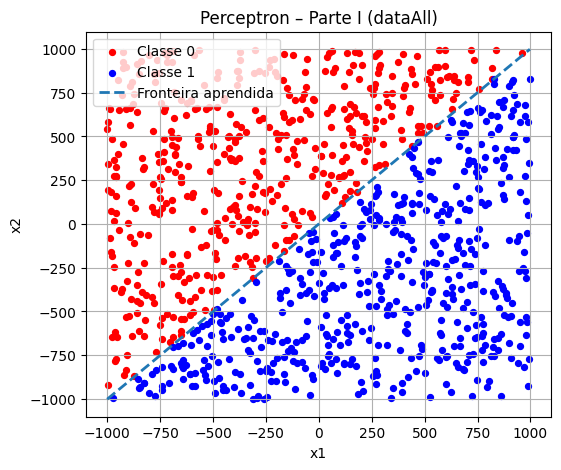

In [3]:
# === PARTE 1 (ENXUTA) ===
# Requisitos: degrau (θ=0), eta=0.1, w0~U(-0.5,0.5), até convergência, imprimir infos e plotar reta.
import numpy as np
import matplotlib.pyplot as plt

# 1) Carrega dataAll (binário de floats) e separa X, y
data = np.fromfile("data/dataAll.txt", dtype=float).reshape(-1, 3)
X = data[:, :2]
y = data[:, 2].astype(int)

# 2) Monta X com bias explícito (1.0)
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])  # [1, x1, x2]

# 3) Inicializa pesos em U(-0.5, 0.5)
rng = np.random.default_rng(42)
w = rng.uniform(-0.5, 0.5, size=(3,))  # (w0, w1, w2)
w_init = w.copy()

# 4) Define função degrau (θ=0) e treinamento (Rosenblatt) até convergência
def step(u):  # θ = 0
    return 1 if u >= 0.0 else 0

eta = 0.1
epochs = 0
total_adjustments = 0
max_epochs = 10000  # segurança

while epochs < max_epochs:
    errors = 0
    for xi, yi in zip(X_aug, y):
        u = float(np.dot(w, xi))
        y_hat = step(u)
        e = yi - y_hat
        if e != 0:
            w = w + eta * e * xi
            total_adjustments += 1
            errors += 1
    epochs += 1
    if errors == 0:
        break

# 5) Impressões exigidas
print("Pesos iniciais:", w_init)
print("Total de ajustes:", total_adjustments)
print("Épocas até a convergência:", epochs)

# 6) Gráfico com pontos e reta separadora
cls0 = X[y == 0]
cls1 = X[y == 1]

plt.figure(figsize=(6,5))
plt.scatter(cls0[:,0], cls0[:,1], c='red', s=18, label='Classe 0')
plt.scatter(cls1[:,0], cls1[:,1], c='blue', s=18, label='Classe 1')

# Reta: w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w0 + w1*x1)/w2
w0, w1, w2 = w
x1_min, x1_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
xx = np.linspace(x1_min, x1_max, 200)
if abs(w2) > 1e-12:
    yy = -(w0 + w1*xx)/w2
    plt.plot(xx, yy, '--', linewidth=2, label='Fronteira aprendida')
else:
    xv = -w0 / w1
    plt.axvline(xv, linestyle='--', linewidth=2, label='Fronteira aprendida')

plt.title('Perceptron – Parte I (dataAll)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend(); plt.grid(True)
plt.show()


# Parte II - Experimentação

In [4]:
table = PrettyTable()
table.field_names = ['Taxa de Aprendizado', 'Intervalo de Pesos',
                     'Quantidade de Ajustes', 'Menor número de épocas para convergência']

# Carregamento do dataset
dataset = np.fromfile('data/data1.txt').reshape(-1, 3)
X = dataset[:, :-1].tolist()
y = dataset[:, -1].astype(int).tolist()

# Parâmetros de variação
learning_rates = [0.4, 0.1, 0.01]
weights_intervals = [(-0.5, 0.5), (-100, 100)]

# Repetições
repetition = 10

# Loop principal de teste
for lr in learning_rates:
    for interval in weights_intervals:

        errors = []
        epochs = []

        for i in range(repetition):
            p = Perceptron(learning_rate=lr, interval=interval)
            p.fit(X, y)

            errors.append(p.total_adjustments)
            epochs.append(p.epochs)
            
        mean = np.mean(errors)
        std = np.std(errors)

        table.add_row([
            f'η = {lr}',
            f'{interval}',
            f'{mean:.4f} ± {std:.4f}',
            np.min(epochs)
        ])

# Exibe a tabela
display(table)

Total de 12 épocas
Total de 22 épocas
Total de 20 épocas
Total de 20 épocas


C:\Users\Felix\AppData\Local\Temp\ipykernel_18984\1416119088.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w)) # soma cada elemento preditor com seu peso correspondente


Total de 36 épocas
Total de 21 épocas
Total de 20 épocas
Total de 20 épocas
Total de 18 épocas
Total de 21 épocas
Total de 13 épocas
Total de 23 épocas
Total de 23 épocas
Total de 15 épocas
Total de 12 épocas
Total de 17 épocas
Total de 3 épocas
Total de 21 épocas
Total de 32 épocas
Total de 40 épocas
Total de 13 épocas
Total de 24 épocas
Total de 17 épocas
Total de 17 épocas
Total de 34 épocas
Total de 16 épocas
Total de 16 épocas
Total de 15 épocas
Total de 13 épocas
Total de 29 épocas
Total de 42 épocas
Total de 49 épocas
Total de 126 épocas
Total de 41 épocas
Total de 24 épocas
Total de 52 épocas
Total de 127 épocas
Total de 17 épocas
Total de 34 épocas
Total de 24 épocas
Total de 2 épocas
Total de 17 épocas
Total de 2 épocas
Total de 15 épocas
Total de 7 épocas
Total de 8 épocas
Total de 7 épocas
Total de 6 épocas
Total de 11 épocas
Total de 9 épocas
Total de 809 épocas
Total de 75 épocas
Total de 60 épocas
Total de 256 épocas
Total de 610 épocas
Total de 607 épocas
Total de 601 é

Taxa de Aprendizado,Intervalo de Pesos,Quantidade de Ajustes,Menor número de épocas para convergência
η = 0.4,"(-0.5, 0.5)",47.0000 ± 10.8074,12
η = 0.4,"(-100, 100)",446.2000 ± 148.7628,3
η = 0.1,"(-0.5, 0.5)",44.1000 ± 13.6121,13
η = 0.1,"(-100, 100)",1527.0000 ± 748.5720,17
η = 0.01,"(-0.5, 0.5)",68.0000 ± 30.6594,2
η = 0.01,"(-100, 100)",17042.3000 ± 6039.9066,60


# Discussão Crítica

## Taxa de Aprendizado

A taxa de aprendizado mostra uma relação significativa com o intervalo de inicialização dos pesos. Embora taxas maiores, como `η = 0.4`, geralmente levem a uma convergência mais rápida, isso depende fortemente do intervalo dos pesos iniciais. Por exemplo, a combinação `η = 0.4` com o intervalo `(-100, 100)` apresenta desempenho comparável ao de `η = 0.01` com o intervalo `(-0.5, 0.5)` em termos de menor número de épocas. No entanto, a quantidade de ajustes necessários varia drasticamente entre os cenários, indicando que uma taxa maior nem sempre significa maior eficiência no processo de aprendizado como um todo.

## Intervalo de Pesos

O intervalo de inicialização dos pesos tem um impacto direto na eficiência do treinamento. Utilizar um intervalo muito amplo, como `(-100, 100)`, tende a tornar o processo de convergência significativamente mais ineficiente — tanto em número de ajustes quanto em variação dos resultados. Em contraste, intervalos menores como `(-0.5, 0.5)` promovem uma convergência mais estável e com menos ajustes, mesmo quando utilizadas taxas de aprendizado pequenas. A quantidade de ajustes cresce de forma quase exponencial com o aumento do intervalo, sugerindo que inicializações com valores mais concentrados em torno de zero favorecem a aprendizagem do Perceptron.

## Conclusão

A análise evidencia que tanto a taxa de aprendizado quanto o intervalo de inicialização dos pesos têm um papel crucial na eficiência do Perceptron. Enquanto taxas mais altas podem acelerar a convergência, isso só ocorre de forma consistente quando os pesos são inicializados em intervalos moderados. Já intervalos muito amplos introduzem instabilidade e aumentam significativamente o número de ajustes, mesmo com taxas de aprendizado pequenas.

Portanto, para aplicações práticas, recomenda-se utilizar taxas de aprendizado moderadas (`η = 0.1` ou `η = 0.4`) combinadas com intervalos de pesos mais restritos (como `(-0.5, 0.5)`), garantindo melhor desempenho e menor custo computacional. Ajustes excessivos e lentidão no treinamento podem ser evitados com escolhas apropriadas desses hiperparâmetros.


### Parte III - Validação _Holdout_ em Problema Não-Linearmente Separável

In [5]:
# Carregar dados
data_holdout = np.fromfile("./data/dataHoldout.txt", dtype=float).reshape(-1, 3)

In [6]:
# Preparar X e Y
X = data_holdout[:, :2]
y = data_holdout[:, 2].astype(int)

In [7]:
# Verificando as primeiras entradas 
print(X[:5])
print(y[:5])

[[-0.29322959 -0.09065359]
 [ 0.07988839  0.21101297]
 [-0.07825563 -0.08083512]
 [-0.46833414 -0.10620722]
 [ 0.46304142  0.09405471]]
[1 1 1 1 1]


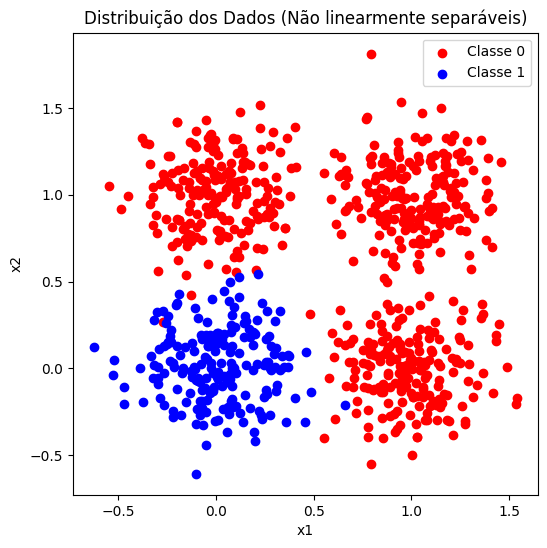

In [8]:
# Verificando a Não-Linearidade do Conjunto de Dados
x1 = X[:, 0]
x2 = X[:, 1]
# Classes em cores
colors = ['red' if label == 0 else 'blue' for label in y]

plt.figure(figsize=(6,6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Classe 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Classe 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Distribuição dos Dados (Não linearmente separáveis)')
plt.show()

In [9]:
# Holdout split 70/30

# Aleatoriedade com base no identificador do grupo
identificador = 1
np.random.seed(identificador)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=identificador, shuffle=True
)


In [10]:
# Treinamento do Perceptron
p = Perceptron(max_epochs=100)
p.fit(X_train.tolist(), y_train.tolist(), shuffle=True)

C:\Users\Felix\AppData\Local\Temp\ipykernel_18984\1416119088.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w)) # soma cada elemento preditor com seu peso correspondente


Total de 100 épocas


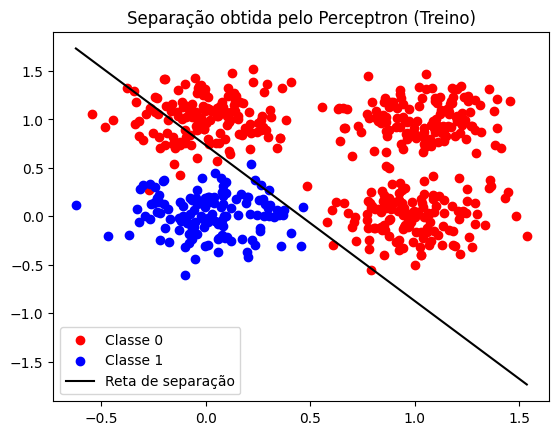

In [11]:
# Plotando reta de separação possível
w = p.w
x1 = np.linspace(min(X_train[:,0]), max(X_train[:,0]), 100)
x2 = -(w[0]*x1 + w[2]) / w[1] 

plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color="red", label="Classe 0")
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.legend()
plt.title("Separação obtida pelo Perceptron (Treino)")
plt.show()

C:\Users\Felix\AppData\Local\Temp\ipykernel_18984\1416119088.py:15: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  activation = np.sum(xi * w for xi, w in zip(x, self.w)) # soma cada elemento preditor com seu peso correspondente


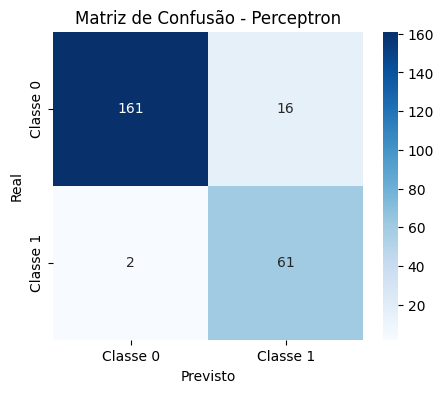

In [12]:
# Avaliando no conjunto de teste
y_pred = p.predict(X_test.tolist())

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Perceptron")
plt.show()

In [13]:
# Acurácia, Precisão, Revocação e F1-Score
correct = sum(1 for yi, yp in zip(y_test, y_pred) if yi == yp)
accuracy = correct / len(y_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Revocação: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Acurácia: 0.9250
Precisão: 0.7922
Revocação: 0.9683
F1-score: 0.8714


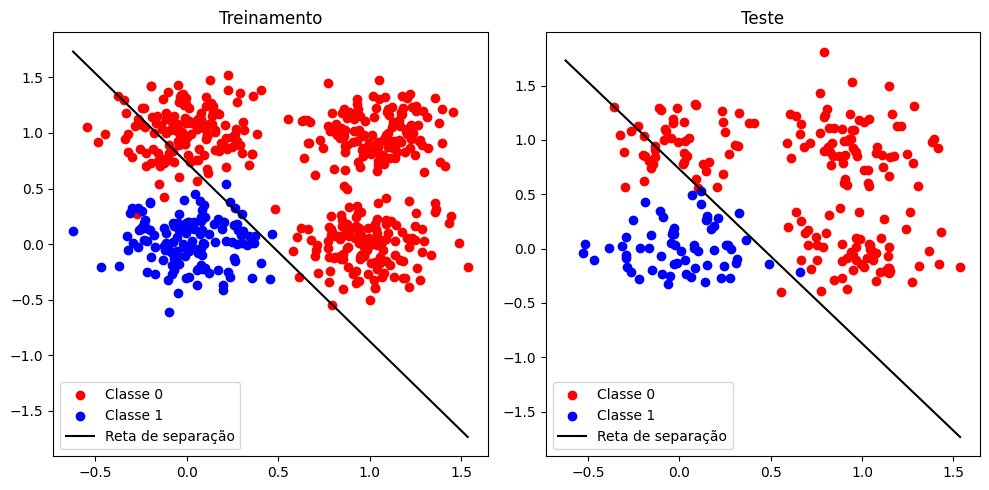

In [14]:
# Criar gráfico lado a lado
plt.figure(figsize=(10,5))

# Subplot 1 - Treinamento
plt.subplot(1,2,1)
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color="red", label="Classe 0")
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.title("Treinamento")
plt.legend()

# Subplot 2 - Teste
plt.subplot(1,2,2)
plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1], color="red", label="Classe 0")
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], color="blue", label="Classe 1")
plt.plot(x1, x2, color="black", label="Reta de separação")
plt.title("Teste")
plt.legend()

# Ajusta layout e mostra tudo junto
plt.tight_layout()
plt.show()


Conclusões

Embora o problema seja não linearmente separável, os resultados do Perceptron foram satisfatórios. A acurácia obtida no conjunto de testes foi de 92,5%, com precisão de 79,22%, revocação de 96,83% e F1-score de 87,14%. Esses valores indicam que o modelo foi capaz de capturar bem o padrão presente nos dados, ainda que apresente algumas falhas na identificação de exemplos positivos (precisão mais baixa).
Em resumo, mesmo limitado por sua natureza linear, o Perceptron conseguiu oferecer uma separação consistente, confirmando sua utilidade em problemas simples, embora não seja a solução ideal para dados que não são linearmente separáveis.

Sobre a linha de decisão obtida pelo Perceptron, observa-se que a mesma não se ajusta perfeitamente à distribuição dos dados, já que o problema não é linearmente separável, conforme o esperado. Ainda assim, a solução encontrada pelo modelo apresenta boas métricas de desempenho, como acurácia superior a 90%. Isso confirma que, mesmo não representando perfeitamente os limites entre as classes, o Perceptron foi capaz de capturar um padrão útil nos dados.